# 02 Collect Sources

USGS active streamgages, STREAM-geo/NLDI river geometry, reservoir conditions, direct AORC SST rainfall members, and NWM soil-moisture context.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

# plan reruns, reuse reviewed data, and audit readiness.
import design_events.collect_sources.workflow as collect
from design_events.collect_sources.nwm import soil_moisture_csv_has_variables
from design_events.collect_sources.usgs_streamgages import discover_active_streamgage_candidates, write_reviewed_streamgage_network


runtime = collect.load_runtime(location_root)
config = runtime.runtime_config
paths = runtime.runtime_paths

display(collect.summary(config, paths))
display(collect.source_records(runtime))


location                                                       austin
sources_root        /home/grahamhults/projects/Flood-RM/locations/...
collection_start                                           1979-02-01
collection_end                                             2022-12-31
Name: source_collection, dtype: str

,record,configured,location_root_syntax,exists
0,active USGS streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,True
1,reviewed streamgage network,data/sources/usgs_streamgages/streamgage_netwo...,"location_root / ""data/sources/usgs_streamgages...",True
2,reviewed discharge records,data/sources/usgs_streamgages/streamflow_recor...,"location_root / ""data/sources/usgs_streamgages...",True
3,AORC rainfall members,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,True
4,NWM soil-moisture members,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,True
5,STREAM-geo river geometry cache,data/sources/national_hydrography/stream_geo.p...,"location_root / ""data/sources/national_hydrogr...",True
6,NLDI STREAM-geo COMID join cache,data/sources/national_hydrography/nldi_stream_...,"location_root / ""data/sources/national_hydrogr...",False
7,NHDPlusV2 flowlines for STREAM-geo join,data/sources/national_hydrography/nhdplus_v2_f...,"location_root / ""data/sources/national_hydrogr...",False
8,NHDPlus river geometry,data/sources/national_hydrography/nhdplus_hr_r...,"location_root / ""data/sources/national_hydrogr...",True
9,NHDPlus catchments,data/sources/national_hydrography/nhdplus_hr_c...,"location_root / ""data/sources/national_hydrogr...",True


## Rerun Control


In [2]:
force_source_collection_refresh = False
refresh_wflow_hydrography_only = False
source_skip_existing = not force_source_collection_refresh
rerun = force_source_collection_refresh


## Source Collection Plan

In [3]:
plan = collect.plan(config, paths)
plan_table = collect.plan_table(
    plan,
    paths,
    rerun=rerun,
)
display(plan_table)


,source,start,end,will_reuse_existing,action
0,usgs_streamgages,1979-02-01,2022-12-31,True,reuse complete artifact
1,lcra_hydromet,1979-02-01,2022-12-31,False,collect or repair
2,national_hydrography,1979-02-01,2022-12-31,True,reuse complete artifact
3,nwm,1979-02-01,2022-12-31,True,reuse complete artifact
4,aorc_sst,1979-02-01,2022-12-31,True,reuse complete artifact


## USGS Active Streamgage Discovery

In [4]:
discovery_summary, records_summary = collect.discover_gages(runtime)
display(discovery_summary)
display(records_summary)
display(collect.gage_readiness(runtime))


provider                                                           USGS NWIS
site_service_url                   https://waterservices.usgs.gov/nwis/site/
parameter_cd                                                           00060
site_status                                                           active
data_types                                                              None
bbox                                -98.370226,30.023614,-97.587078,30.82078
search_geometry             data/static/aoi/wflow_nhdplus_watersheds.geojson
hydrologic_buffer_km                                                    None
active_records_only                                                     True
candidate_output           /home/grahamhults/projects/Flood-RM/locations/...
candidate_output_exists                                                 True
Name: usgs_active_streamgage_discovery, dtype: object

records_service                                                           dv
records_output             data/sources/usgs_streamgages/streamflow_recor...
records_output_exists                                                   True
request_timeout_seconds                                                   60
stat_cd                                                                00003
Name: usgs_reviewed_discharge_records, dtype: object

,artifact,path,exists,ready
0,streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,False
9,soil moisture,/home/grahamhults/projects/Flood-RM/locations/...,True,True


## Stochastic Storm Transposition Region

The SST region is defined in `config.yaml`

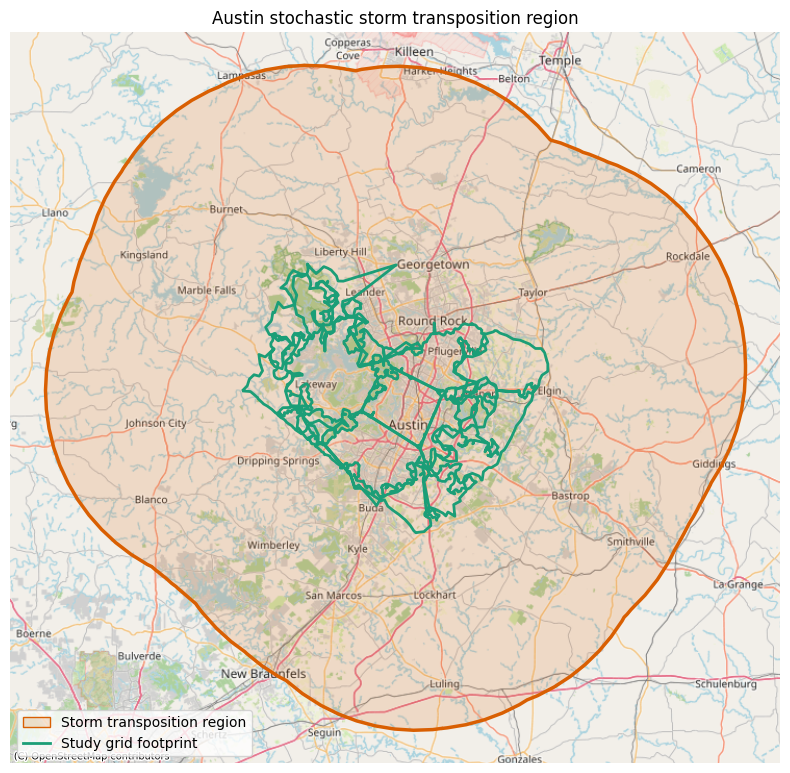

In [5]:
# Plot the configured AORC SST transposition region before pulling rainfall members.
fig, ax = collect.plot_sst_region(config, paths)

## STREAM-geo/NLDI River Geometry

STREAM-geo width/depth estimates are cached for native Wflow river-geometry enrichment; NLDI is retained as the COMID lookup provenance path.


In [6]:
display(collect.stream_sources(config, paths))


source                                                           STREAM-geo/NLDI
stream_geo_table               data/sources/national_hydrography/stream_geo.p...
stream_geo_table_exists                                                     True
nldi_lookup_cache              data/sources/national_hydrography/nldi_stream_...
nldi_lookup_cache_exists                                                   False
nhdplus_v2_flowlines           data/sources/national_hydrography/nhdplus_v2_f...
nhdplus_v2_flowlines_exists                                                False
stream_geo_join_method                                        attribute_transfer
nldi_role                                                COMID lookup provenance
manifest                       /home/grahamhults/projects/Flood-RM/locations/...
manifest_exists                                                             True
Name: stream_geo_nldi, dtype: object

## Reservoir Condition Inputs

TWDB reservoir history is cached for Austin Highland Lakes so Wflow reservoir area, storage, and equivalent depth use source-backed conditions instead of bootstrap defaults.


In [7]:
display(collect.reservoir_sources(config, paths))


enabled                                                           True
provider                                     twdb_water_data_for_texas
period_suffix                                                   -1year
statistic                                                       median
reservoir_slugs         austin, lyndon-b-johnson, marble-falls, travis
summary_csv          /home/grahamhults/projects/Flood-RM/locations/...
summary_exists                                                    True
provenance_json      /home/grahamhults/projects/Flood-RM/locations/...
provenance_exists                                                 True
Name: reservoir_conditions, dtype: object

## Direct AORC SST Rainfall Members

The direct AORC SST collector scans the transposition region, ranks rolling storm windows, and writes the rainfall-member table for precipitation pairing with streamflow and antecedent soil-moisture states.


In [8]:
# --- AORC SST collection parameters (edit to retune, then run Run Collection below) ---
# Threshold-driven POT: keep every INDEPENDENT storm whose 72h footprint-mean depth
# exceeds the threshold, so the rainfall-member count is data-driven
# Set the threshold from the rainfall POT diagnostics; raise it for fewer, heavier members.
min_precip_threshold = 40.0   # mm over the 72h storm window (footprint mean)
decluster_hours = 72          # minimum spacing between independent storms
storm_duration_hours = 72     # SST rainfall accumulation window
check_every_n_hours = 6       # transposition scan stride
defer_event_windows = True    # write AORC event-window NetCDFs, including Wflow meteo, in the separate cell below

display(collect.aorc_sst_params(
    config,
    paths,
    min_precip_threshold=min_precip_threshold,
    decluster_hours=decluster_hours,
    storm_duration_hours=storm_duration_hours,
    check_every_n_hours=check_every_n_hours,
    defer_event_windows=defer_event_windows,
))


source                                                       direct_aorc_sst
transposition_region_id                        austin-inland-review-required
transposition_region       data/sources/aorc_sst/transposition_regions/tr...
start_date                                                        1979-02-01
end_date                                                          2022-12-31
selection                  threshold-driven POT (every independent storm ...
min_precip_threshold_mm                                                 40.0
storm_duration_hours                                                      72
decluster_hours                                                           72
check_every_n_hours                                                        6
top_n_events_safety_cap                                                 None
defer_event_windows                                                     True
event_meteo_enabled                                                     True

### AORC Re-Collect

Use this when the rainfall SST source tables need to be regenerated without rerunning the rest of the source collection plan. Re-collection repopulates the true `rainfall_peak_time` used for the inland Event Reference Time and storm-timing descriptors (ADR-0019).

In [9]:
# Refresh only AORC SST rainfall source tables, leaving USGS/NWM/reservoir/etc. untouched.
refresh_aorc_sst_only = True

if refresh_aorc_sst_only:
    from design_events.collect_sources.aorc_sst import collect_aorc_sst

    aorc_sst_refresh_result = collect_aorc_sst(
        plan.settings_for("aorc_sst"),
        skip_existing=True,
    )
    display(pd.Series(aorc_sst_refresh_result, name="aorc_sst_refresh"))

    storm_stats_columns = set(pd.read_csv(
        paths["aorc_sst_root"] / paths["location_name"] / f"{storm_duration_hours}hr-events" / "storm-stats.csv",
        nrows=0,
    ).columns)
    rainfall_member_columns = set(pd.read_csv(paths["aorc_sst_rainfall_members_csv"], nrows=0).columns)
    display(pd.Series({
        "storm_stats_has_rainfall_peak_time": "rainfall_peak_time" in storm_stats_columns,
        "rainfall_members_has_rainfall_peak_time": "rainfall_peak_time" in rainfall_member_columns,
    }, name="aorc_sst_refresh_check"))

AORC SST years:   0%|          | 0/44 [00:00<?, ?year/s]

ranked_rows                                                           494
storm_stats_rows                                                    63676
rainfall_member_rows                                                  494
event_window_count                                                      0
ranked_storms_csv       /home/grahamhults/projects/Flood-RM/locations/...
storm_stats_csv         /home/grahamhults/projects/Flood-RM/locations/...
source_artifact_json    /home/grahamhults/projects/Flood-RM/locations/...
Name: aorc_sst_refresh, dtype: object

storm_stats_has_rainfall_peak_time         True
rainfall_members_has_rainfall_peak_time    True
Name: aorc_sst_refresh_check, dtype: bool

## NWM Soil-Moisture Context

Selected NWM LDAS soil-moisture cells are retained for antecedent-condition pairing. Inland streamflow frequency uses reviewed USGS gages, so NWM streamflow remains context rather than the production frequency source.


In [10]:
soil_variables = config["collection"]["nwm"]["soil_moisture"]["variables"]
soil_moisture_path = runtime.resolve_location_path(config["event_catalog"]["forcing_members"]["soil_moisture"])
soil_moisture_ready = soil_moisture_csv_has_variables(soil_moisture_path, soil_variables)
display(collect.soil_sources(config, paths))
display(pd.Series({"soil_moisture_path": soil_moisture_path, "soil_moisture_ready": soil_moisture_ready}, name="nwm_soil_moisture_readiness"))

version                                                                               None
streamflow_available                                                                  None
streamflow_reason                                                                     None
soil_moisture_points                                                                     0
soil_moisture_variables                                                                 []
soil_moisture_zarr                                                                    None
soil_moisture_csv                        /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_exists                                                                  True
soil_moisture_has_requested_variables                                                 True
Name: nwm_soil_moisture, dtype: object

soil_moisture_path     /home/grahamhults/projects/Flood-RM/locations/...
soil_moisture_ready                                                 True
Name: nwm_soil_moisture_readiness, dtype: object

## Run Collection

In [11]:
# Collect any missing configured sources and summarize the artifacts.
collectable_readiness = collect.readiness(runtime)
collect_missing_sources = force_source_collection_refresh or not collectable_readiness["ready"].all()
if refresh_wflow_hydrography_only:
    display(pd.Series(collect.refresh_wflow_hydrography_basemap(runtime, force=True), name="wflow_hydrography_basemap_refresh"))
prerequisite_result = collect.prepare(config, paths)
collection_result = collect.run_collect(
    config,
    paths,
    plan,
    run_collection=collect_missing_sources,
    skip_existing=source_skip_existing,
    stop_on_error=False,
    progress=True,
)
display(pd.concat([
    collectable_readiness.assign(table="pre_collection_readiness"),
    prerequisite_result.assign(table="collection_prerequisite"),
    collection_result.assign(table="collection_result"),
], ignore_index=True, sort=False))


NWM: reusing complete production artifacts in /home/grahamhults/projects/Flood-RM/locations/austin/data/sources/nwm
AORC SST: reusing complete rainfall catalog /home/grahamhults/projects/Flood-RM/locations/austin/data/sources/aorc_sst/austin/72hr-events/ranked-storms.csv


,artifact,path,exists,ready,table,status,source_geometry,buffer_km,review_status,source,duration_seconds,rows
0,streamgage candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,False,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,STREAM-geo river geometry cache,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NLDI STREAM-geo COMID join cache,/home/grahamhults/projects/Flood-RM/locations/...,False,False,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NHDPlusV2 flowlines for STREAM-geo join,/home/grahamhults/projects/Flood-RM/locations/...,False,False,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,wflow HydroMT hydrography basemap,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,wflow US hydrography river geometry,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,wflow US hydrography catchments,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,wflow SSURGO soil parameters,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,rainfall members,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,soil moisture,/home/grahamhults/projects/Flood-RM/locations/...,True,True,pre_collection_readiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## AORC SST Event Windows

In [12]:
# Materialize per-storm AORC event-window NetCDFs with paired precip + Wflow meteo.
# First-time runs should use the full collection path below. Set
# repair_missing_event_meteo_only=True only as an explicit recovery path for legacy
# event-window files that already contain rainfall but lack finite Wflow meteo fields.
repair_missing_event_meteo_only = False
skip_existing_event_windows = True
if repair_missing_event_meteo_only:
    aorc_event_window_result = collect.repair_aorc_sst_event_window_meteo(
        config,
        paths,
        plan,
        skip_existing=skip_existing_event_windows,
    )
else:
    aorc_event_window_result = collect.collect_aorc_sst_event_windows(
        config,
        paths,
        plan,
        skip_existing=skip_existing_event_windows,
    )
display(aorc_event_window_result)

aorc_event_window_readiness = collect.aorc_sst_event_window_readiness(config, paths, plan)
display(aorc_event_window_readiness)
if aorc_event_window_readiness["status"] != "ready":
    raise RuntimeError(
        "AORC event windows are not ready for paired Wflow/SFINCS forcing: "
        f"{aorc_event_window_readiness.to_dict()}"
    )


AORC selected storm windows:   0%|          | 0/494 [00:00<?, ?storm/s]

source                                             aorc_sst_event_windows
status                                                          collected
ranked_rows                                                           494
rainfall_member_rows                                                  494
event_window_count                                                    494
ranked_storms_csv       /home/grahamhults/projects/Flood-RM/locations/...
event_windows_dir       /home/grahamhults/projects/Flood-RM/locations/...
source_artifact_json    /home/grahamhults/projects/Flood-RM/locations/...
Name: aorc_sst_event_windows, dtype: object

source                                 aorc_sst_event_window_readiness
status                                                           ready
ranked_rows                                                        494
ready_count                                                        494
missing_count                                                        0
incomplete_count                                                     0
event_windows_dir    /home/grahamhults/projects/Flood-RM/locations/...
Name: aorc_sst_event_window_readiness, dtype: object

## Reservoir Condition Review

Matched TWDB condition records update the Wflow reservoir source layer; unmatched reservoirs remain review-flagged.


In [13]:
reservoir_conditions = collect.reservoir_condition_table(config, paths)
display(reservoir_conditions)


,waterbody_name,twdb_slug,condition_status,condition_statistic,condition_period_start,condition_period_end,Depth_avg,reservoir_storage_acft,surface_area_acres,percent_full,condition_reason
0,Lake Travis,travis,matched,median,2025-06-23,2026-06-23,16.940778,888132.5,15979.36,79.35,NaN
1,Lake Lyndon B Johnson,lyndon-b-johnson,matched,median,2025-06-23,2026-06-23,6.177359,129821.0,6405.56,98.40,NaN
2,Lake Austin,austin,matched,median,2025-06-23,2026-06-23,4.667799,23690.0,1546.92,96.30,NaN
3,NaN,NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no configured TWDB slug
4,Lake Marble Falls,marble-falls,matched,median,2025-06-23,2026-06-23,3.658817,7215.0,601.05,95.00,NaN
5,Lady Bird Lake,NaN,missing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no configured TWDB slug


## Reviewed Streamgage Network Writer


In [14]:
write_reviewed_streamgage_network_file = True
reviewed_network_decisions = collect.build_reviewed_streamgage_decisions(config, paths)
reviewed_streamgage_decision_table = pd.DataFrame(reviewed_network_decisions)
if write_reviewed_streamgage_network_file:
    reviewed_network_result = write_reviewed_streamgage_network(config, paths, reviewed_network_decisions)
else:
    reviewed_network_result = {
        "status": "review_pending",
        "reviewed_network_geojson": str(runtime.reviewed_network_path),
        "accepted_count": int(reviewed_streamgage_decision_table["review_status"].str.startswith("accepted").sum()),
        "reason": "Review candidate gages, then set write_reviewed_streamgage_network_file=True.",
    }

display(reviewed_streamgage_decision_table)
display(pd.Series(reviewed_network_result, name="reviewed_streamgage_network"))

# USGS Reviewed Discharge Records
reviewed_records_result = collect.collect_gage_records(runtime, skip_existing=source_skip_existing)
display(pd.Series(reviewed_records_result, name="usgs_reviewed_discharge_records"))


,site_no,review_status,roles,frequency_basis,wflow_submodel_id,sfincs_domain_id,sfincs_handoff_id,review_notes
0,08154700,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
1,08155200,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
2,08155240,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
3,08155300,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
4,08155400,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
5,08155500,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
6,08155541,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
7,08156675,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
8,08156800,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...
9,08156910,accepted_with_warning,"[frequency, calibration, validation]",austin_p5u,austin_p5u,austin_p5u,None,HUC-derived active discharge gage inside 12090...


reviewed_network_geojson    /home/grahamhults/projects/Flood-RM/locations/...
reviewed_count                                                             32
accepted_count                                                             32
Name: reviewed_streamgage_network, dtype: object

reused                                                                         False
site_count                                                                        32
record_count                                                                  278085
streamflow_records_csv             /home/grahamhults/projects/Flood-RM/locations/...
source_artifact_json               /home/grahamhults/projects/Flood-RM/locations/...
missing_sites_before_collection             [08157560, 08158045, 08158823, 08158824]
Name: usgs_reviewed_discharge_records, dtype: object

## Collected Data Overview

In [15]:
display(collect.overview())

,driver,source,event_use
0,streamflow,USGS active streamgages,POT frequency basis and Wflow validation
1,rainfall,AORC SST,direct rainfall and Wflow precipitation forcing
2,soil_moisture,NWM retrospective,antecedent state pairing


### SST

Storm transposition targets are plotted against the configured SST region and study area.


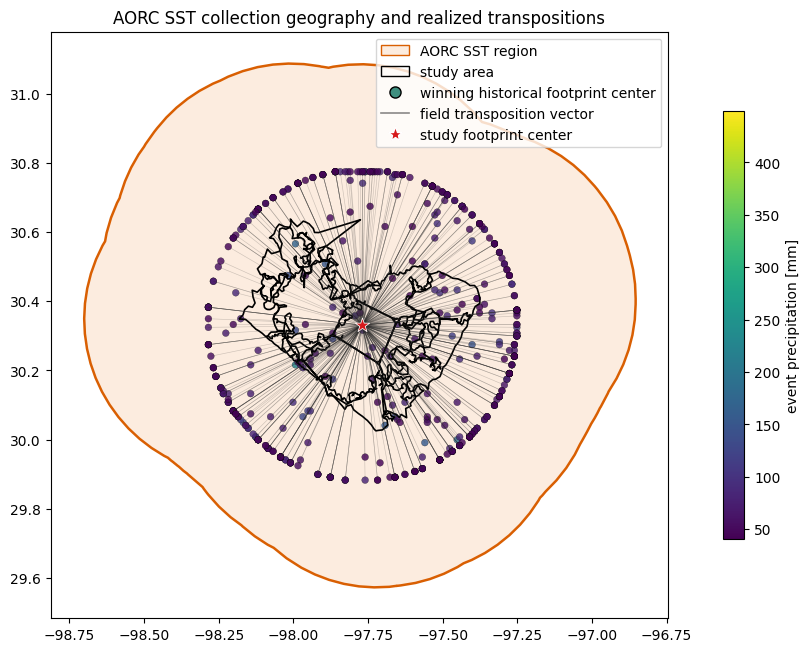

In [16]:
# Plot the SST region, study area, and rainfall transposition targets.
fig, ax = collect.plot_collected_sst_geography(config, paths)

### USGS Streamgages

Reviewed streamgages are plotted against the same source geography used during the review gate: evaluation footprint, SFINCS coverage, Wflow watershed search domain, and SST region.


,artifact,label,path,exists,feature_count
0,candidate active gages,all active candidates,/home/grahamhults/projects/Flood-RM/locations/...,True,44
1,reviewed streamgage network,reviewed artifact,/home/grahamhults/projects/Flood-RM/locations/...,True,32
2,area layer,SMART-DS evaluation footprint,/home/grahamhults/projects/Flood-RM/locations/...,True,6
3,area layer,SFINCS coverage bbox,/home/grahamhults/projects/Flood-RM/locations/...,True,1
4,area layer,Wflow watershed search domain,/home/grahamhults/projects/Flood-RM/locations/...,True,1
5,area layer,AORC SST transposition region,/home/grahamhults/projects/Flood-RM/locations/...,True,1
6,used_reviewed_gages,active accepted gages,/home/grahamhults/projects/Flood-RM/locations/...,True,32
7,other_candidate_gages,active candidates not in reviewed network,/home/grahamhults/projects/Flood-RM/locations/...,True,12


,check,value,path
0,configured NWIS search bbox covers Wflow water...,True,/home/grahamhults/projects/Flood-RM/locations/...
1,active candidate gages inside Wflow watershed,32 of 44,/home/grahamhults/projects/Flood-RM/locations/...
2,reviewed gages inside Wflow watershed,32 of 32,/home/grahamhults/projects/Flood-RM/locations/...
3,active accepted reviewed gages inside Wflow wa...,32 of 32,/home/grahamhults/projects/Flood-RM/locations/...


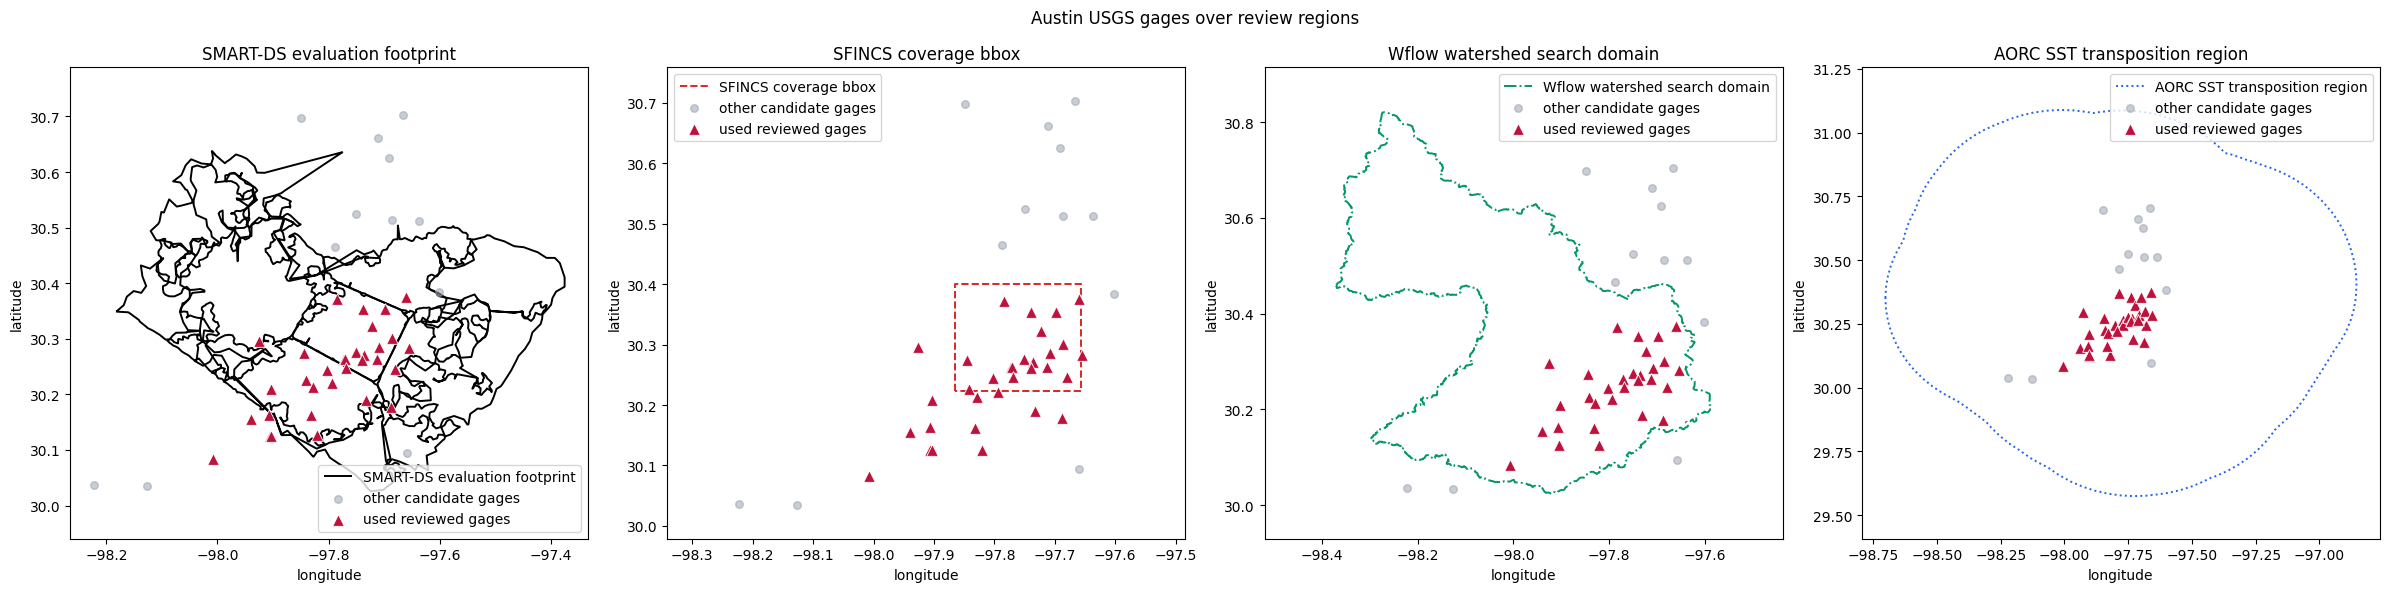

In [17]:
# Plot reviewed and candidate USGS streamgages over the source review geography.
fig, artifact_summary, gage_domain_summary = collect.plot_usgs_streamgage_network(runtime)
display(artifact_summary)
display(gage_domain_summary)

### NWM Soil Moisture

Soil moisture is summarized across configured NWM points and layers.


requested_variables                                                   []
available_variables                                             [SOIL_M]
missing_variables                                                     []
csv                    /home/grahamhults/projects/Flood-RM/locations/...
Name: nwm_soil_moisture_status, dtype: object

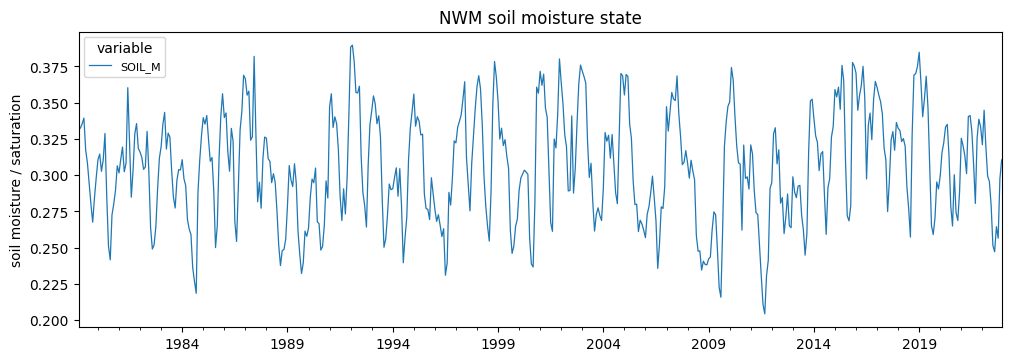

In [18]:
# Plot monthly mean NWM soil moisture variables when available.
fig, status = collect.plot_nwm_soil_moisture(config, paths)
display(status)

### AORC SST Rainfall

Rainfall members are shown as selected-event magnitude and distribution summaries.


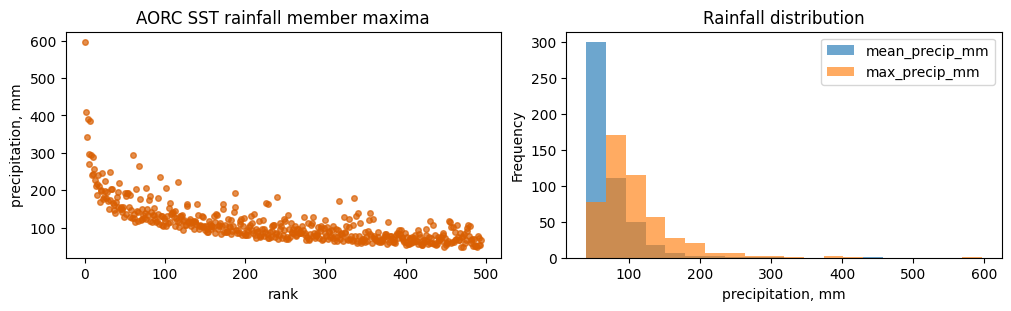

In [19]:
# Plot compact AORC SST rainfall member summaries.
fig = collect.plot_aorc_sst_rainfall(paths)